# Лабораторная работа 3
### Выполнил: Дышлевский Константин Евгеньевич

### Предисловие

В общем, многие из вещеий которые хорошо было бы сделать, я не делал. Я тупо честно говоря не смотрел в новый шаблон лабы. Скорее всего в лабе они появится для наглядности, но все эксперименты я проводил без них. Там был типа один график лосса на батче, и отрисовка картинок с точками.

### EDA (исследовательский анализ данных)

Минутка веселых подключений

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import random
import torchvision.transforms.functional as F
import torchvision.transforms as T
from torchvision.transforms import v2
import torch.nn as nn
import os
from pathlib import Path
from PIL import Image
import pandas as pd
from IPython import display
from sklearn.model_selection import train_test_split

In [94]:
my_seed = 123456

In [95]:
random.seed(my_seed)
np.random.seed(my_seed)
torch.random.seed = my_seed

In [4]:
def draw_with_dots(img: Image, dots: torch.Tensor):
    plt.imshow(img)
    for i in range(len(dots)//2):
        plt.plot(dots[i*2], dots[i*2+1], 'ro')

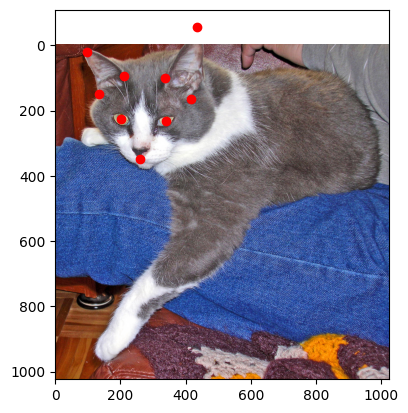

In [7]:
img = Image.open('images\\train\\76ae4bd22213d18c430271c1af450c89.jpg')
dots = [201.0,225.0,340.0,231.0,260.0,349.0,134.0,148.0,98.0,20.0,210.0,95.0,337.0,100.0,435.0,-55.0,417.0,165.0]
draw_with_dots(img, dots)

<b>"В этой лабораторной вы работаете с картинками. Напишите функцию, которая отрисовывала бы ключевые точки на конкретном изображении, это вам пригодится для дебага. 
Можете посчитать статистики по картинкам в датасете."</b>

Вот я в прошлой лабе жаловался что там графиков приколных не построишь, и ничего интересного не посчитаешь а тут ... 

Ну я посмотрел каких размеров есть изображения. Зачем? Вопрос хороший. Сделаю вид что ориентрировался на это когда выбирал до какого размера сжимать изображения)))

In [5]:
dirs = os.listdir('images\\train')
test_dirs = os.listdir('images\\test')

In [9]:
width = []
height = []
for i in dirs:
    img = Image.open('images\\train\\'+i)
    width.append(img.size[0])
    height.append(img.size[1])
    

(array([   5.,   59., 1362.,  416., 4617.,   21.,  214.,  305.,   51.,
        1945.]),
 array([ 135. ,  223.9,  312.8,  401.7,  490.6,  579.5,  668.4,  757.3,
         846.2,  935.1, 1024. ]),
 <BarContainer object of 10 artists>)

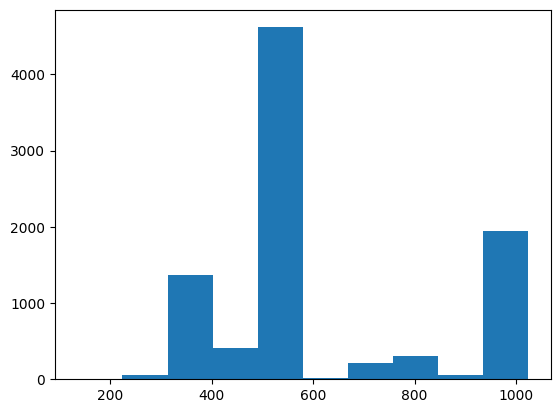

In [10]:
plt.hist(width)

(array([   9.,   74., 3864.,  669., 1849.,   56.,  638., 1039.,   79.,
         718.]),
 array([ 101. ,  193.3,  285.6,  377.9,  470.2,  562.5,  654.8,  747.1,
         839.4,  931.7, 1024. ]),
 <BarContainer object of 10 artists>)

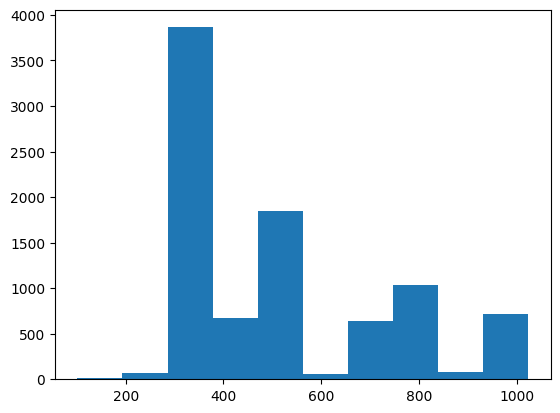

In [9]:
plt.hist(height)

СПОЙЛЕР

Коты с маленькими мордами(на картинке всмысле а не коты карлики) это ужас. Сети просто с ума сходят. Там точки нагромождаются просто как попало. Беда такая, что на больших мордах небольшй промах воспринимается людьми как "ой ну чуть-чуть в ушко не попало, ну ладно", а в маеньких как "почему у тебя глаз на усах?". Я как-то этой проблемы сильно не предвидел и решать как-то не пытался. И вот сидя 6-го числа я думаю что смеха ради можно было бы написать сетку которая бы находила лицо кота, потом брать с картинки только морду кота, все картинки приводить в один размер, делать предикт, а потом разворачивать результаты. Но наверное уже поздновато.

Вообще хочу сказать отличный датасет. Я вместо того чтобы делать кегл 3 дня залипал на картинки котов.

Жаловаться не на что.

Ну ладно почти не на что.

Глобально большая часть картинок описывается как "кот в анфас почти наверное". Они предположительно хорошие, и на них сеть научится хорошо. Но есть и фоточки которые не так хороши.

1) Коты которые поверенули голову на 45+ градусов. Повернули в плане, что уши смотрят не вертикально а куда-то в сторону.

    1.5 Вислоухие коты)))

2) Коты с ушами за пределами изображения (Как оказалось не аткая это и проблема как окажется позже)
3) Картинки с текстом
4) Картинки на которых два кота. А размечен то соответственно только один. Очень нечестные картинки((( Сеть может идеально угадать кота, но не того
5) Картинки с человеком и котом. А ещё где-то была картинка с попугаем на переднем плане. Или вообще с чем-то что очень мешает понять, а где собственно кот.

### Preprocessing (подготовка данных)

"Мы ожидаем, что в этом разделе вы реализуете кастомный класс для подгрузки данных (cоветуем унаследоваться от `torch.utils.data.Dataset`)."

Самое время не оправдать ожидания.

In [6]:
data = pd.read_csv('train_labels.csv')

In [7]:
pic_size = 128
angle = 0

Две таких вот композиции трансформов я использовал чтобы перегнать картинки в тензоры и радостно запихивать их в torch.

Первый сжимает картинку до 128х128, ибо память компьютера не бесконечная. А потом переводит её в одноканал, ибо по хорошему этого должно быть достаточно чтобы найти части морды кота.(Я справился, занчит и сеть сможет, надеюсь).


СПОЙЛЕР

По итогу сети работаю в одноканале в 128х128. 

Попытки в 3 канала или размером 256х256. НО 3 канала не дали значимой разницы, а 256х256 работает сто тысяч лет и жрёт много памяти. Я в какой-то момент случайно растянул размер файла подкачки до 21.5 гб. Было весело, хотя и не очень приятно.

Конец СПОЙЛЕРа


Второй делает то же самое НО умеет крутить картинку и блюрить её. Блюрить вообще опционально, я пробовал и так и так но СПОЙЛЕР эффекта это не возымело. Но подробнее об этом будет в моделях.

Не то чтобы я менял модель под повернутые картинки, но все же.

Третий перевоит тензор в Image.

In [8]:
transforms = T.Compose([
    T.Resize(size = (pic_size,pic_size)),
    T.Grayscale(num_output_channels=1),
    T.PILToTensor()
])

# Важное уточнение по поводу этого трансформа, я не был уверен как будет работать 
# RandomRotation если там угол переменная, по этому я его в цикле переписывал
transforms_rot = T.Compose([
    v2.Resize(size = (pic_size,pic_size)),
    v2.Grayscale(num_output_channels=1),
    v2.RandomRotation([-angle,-angle]),
    v2.GaussianBlur(3), # Опционально 
    v2.PILToTensor()
])

tr = T.ToPILImage()


А ну и ясное дело раз мы крутим картинку, то и таргеты тоже надо покрутить, вот функция ниже для этого и нужна. Углы в градусах потому что ... потому что.(Мне так захотелось и я так сделал)

In [9]:
def rotate_dots(dots, angle):
    for i in range(len(dots)//2):
        x = (64+(dots[2*i]-64)*np.cos(angle*2*np.pi/360)-(dots[2*i+1]-64)*np.sin(angle*2*np.pi/360))
        y = (64+(dots[2*i]-64)*np.sin(angle*2*np.pi/360)+(dots[2*i+1]-64)*np.cos(angle*2*np.pi/360))
        dots[2*i],dots[2*i+1]=x,y
    return dots

Ну, теперь сделаем датасет(-лоадер).

Это train.

In [10]:
X_train = []
Y_train = []
for i in dirs:
    im = ((Image.open('images\\train\\'+i)))
    dots = []

    a = data[data['file_name'] == i].values

    for i in range(9):
        dots.append(a[0][i*2])
        dots.append(a[0][i*2+1])
    
    for i in range(len(dots)//2): # Картинку мы отскейлили, а значит и таргеты тоже нужно(Вот я поначалу про это забыл и сеть придсказывала лююютую ересь)
        dots[2*i] = dots[2*i]*pic_size//im.size[0]
        dots[2*i+1] = dots[2*i+1]*pic_size//im.size[1]
      
    X_train.append(transforms(im))
    
    Y_train.append(torch.Tensor(dots))    
    
    # for j in range(1):
    #     angle = random.randint(1,359)
    #     transforms_rot = T.Compose([
    #         v2.Resize(size = (pic_size,pic_size)),
    #         v2.Grayscale(num_output_channels=1),
    #         v2.RandomRotation([-angle,-angle]),
    #         v2.GaussianBlur(3),
    #         v2.PILToTensor()
    #     ])
        
    #     rotate_dots(dots, angle)
        
    #     X_train.append(transforms_rot(im))
    
    #     Y_train.append(torch.Tensor(dots)) 
    
    # Оставлю это закомментированным ибо в ходе экспериментов я то добавлял поворот, то убирал и вот так оно и висело 
    
X_train = torch.stack(X_train, dim = 0)
Y_train = torch.stack(Y_train, dim = 0)

Validation выборки не было. Опять. Вот ещё одна вещь за которую мне стыдно. Я малость заигрался. Зото на обучении данных больше было. Я имею в виду, в качестве валидационной выборки была та по которой мы делали предик и я сам который смотрел на те картинки где надо было предсказать точки и методом пристального взгляда(Классный метод кстати, нас на матанализе научили) определял насколько модель хороша. А проверял свои выводы я путем заливания в кегл(Посылок то много). ЧТо тоже так себе подход откровенно говоря ибо в реальных задачах никакого кегла не будет.

С точки зрения логики и правильности стоило бы написать функцию которая мне рисовала бы лосс по эпохам, сделать train_test_split (Ну как сделать, импортировать из sklearn и написать одну строчку ...) и смотреть когда модель начнет переобучаться и терять способность к обобщению. 

Кстати про Loss, чем принципиально MAE от CMAE отличается я честно говоря не понял. Ну то есть CMAE это MAE/18?(Ну в нашем конкретном случае) По сути ведь ничего не меняет. 

Поэтому будем с радостью использовать L1Loss.

А по поводу оптимизатора взял Adam. Причины нет. Я брал разные но по ощщущениям глобальной разницы нет. Так что оставил то, что было последним.(А ну и вообще богоугодно: адам, ева, все дела))) Сдадим кегл с божьей помощью)

In [11]:
X_test = []
orig_lens = [] # Изначальные размеры изображения чтобы потом развернуть картинки
Y_test = []
ctr = 0
for i in test_dirs:
    X_test.append((Image.open('images\\test\\'+i)))

    #print(X_test[-1].size)
    orig_lens.append(X_test[-1].size)

    X_test[-1] = transforms(X_test[-1])
    
    Y_test.append(i)
        
    ctr+=1
X_test = torch.stack(X_test, dim = 0)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)

In [13]:
train_dataset = torch.utils.data.TensorDataset(torch.Tensor(x_train).float(), torch.Tensor(y_train).float())
val_dataset = torch.utils.data.TensorDataset(torch.Tensor(x_test).float(), torch.Tensor(y_test).float())
test_dataset = torch.utils.data.TensorDataset(X_test.float(), X_test)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

Про Stack отдельный момент, ибо я очень долго пытался понять, почему torch.cat вместо 8995 картинок в трех каналах делает 26985 картинок в одном канале.

Ну вот а оказалось, что надо было писать stack. Он классный кстати, сразу получается размерность нужная, и не надо делать никакой unsqueeze.

### Training/evaluation loop

Время очередного разочарования)) Функция удивительным образом тут появится, но изначально её не было. Есть ещё пара моментов за которые я похвалить себя не могу, и вы меня тоже не похвалите. Но уже что сделано то сделано. Буду делать вид, что это хитроумный и многоступенчатый(как мои сети хехе) план. 

In [19]:
def make_net(net, optimizer, n_epoch, criterion, device):

    loss_history = []
    
    train_loss = []
    
    val_loss = []

    for i in range(n_epoch):
        epoch_loss = 0
        for x_batch, y_batch in train_dataloader:

            # Forward
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            predictions = net(x_batch)
            loss = criterion(predictions, y_batch)
            epoch_loss+=loss.item()*x_batch.shape[0]
            # Backward
            loss.backward()
            
            # Update weights
            optimizer.step()
            optimizer.zero_grad()

            loss_history.append(loss.item())
            
        train_loss.append(epoch_loss/7196)
        epoch_loss = 0
        
        
        for x_batch, y_batch in val_dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predictions = net(x_batch)
            loss = criterion(predictions, y_batch)
            epoch_loss+=loss.item()*x_batch.shape[0]
        val_loss.append(epoch_loss/1799)
        
        
        # Visualize
        display.clear_output(wait=True)
        fig, axs = plt.subplots(1,2,figsize = (14,7))
        axs[0].plot(loss_history)
        axs[1].plot(train_loss, color = 'red')
        axs[1].plot(val_loss, color = 'green')

        plt.show()

        print('Current loss: %f' % loss)
    
    device = 'cpu'
    net.to(device)  
    return net

Старый добрый training loop.

### Prediction function

In [17]:
def make_preds(net, columns, test_dataloader):
    test_preds = []
    res = pd.DataFrame(columns = columns)
    ctr = 0
    for x_batch, y_batch in test_dataloader:
        predictions = net(x_batch)

        for i in range(len(predictions)):
            tmp = list(predictions[i].detach().numpy())
            
            for j in range(9):
                tmp[2*j] = tmp[2*j]*orig_lens[ctr][0]/pic_size
                tmp[2*j+1] = tmp[2*j+1]*orig_lens[ctr][1]/pic_size
            
            test_preds.append(tmp+[Y_test[ctr]])

            res.loc[len(res.index)] = test_preds[-1]
            ctr+=1
    return res, test_preds        
    

In [18]:
def show_cats(net, test_dataloader, train_dataloader, val_dataloader):
    fig, axs = plt.subplots(3,4,figsize = (20,15))
    axs[0][0].set_title('train')
    axs[1][0].set_title('validation')
    axs[2][0].set_title('predict')
    for x_batch, y_batch in train_dataloader:
        predictions = net(x_batch)
        
        for j in range(4):
             
            axs[0][j].imshow((tr(x_batch[j])), cmap='gray')
            for i in range(9):
                axs[0][j].plot(predictions[j].int()[2*i], predictions[j].int()[2*i+1], 'ro')
        break
    for x_batch, y_batch in val_dataloader:
        predictions = net(x_batch)
        
        for j in range(4):
             
            axs[1][j].imshow((tr(x_batch[j])), cmap='gray')
            for i in range(9):
                axs[1][j].plot(predictions[j].int()[2*i], predictions[j].int()[2*i+1], 'ro')
        
        break
     
    for x_batch, y_batch in test_dataloader:
        predictions = net(x_batch)
        
        for j in range(4):
             
            axs[2][j].imshow((tr(x_batch[j])), cmap='gray')
            for i in range(9):
                axs[2][j].plot(predictions[j].int()[2*i], predictions[j].int()[2*i+1], 'ro')
        
        return

### Experiments

<b>"В этом разделе задаете архитектуры моделей и ставите эксперименты по обучению. Мы ожидаем, что вы зададите модель в виде класса (унаследуетесь от класса `torch.nn.Module`).

Если вы ставили много экспериментов, приведите их в хронологическом порядке, чтобы мы увидели эволюцию ваших рассуждений. 

Мы ожидаем увидеть графики train/val лоссов и метрик для ваших экспериментов. Мы ожидаем увидеть визуализацию примеров предсказаний."</b>

Модель конечно не в виде класса, прошу прощения, но графики я прикрутил.

#### Эксперимент 1

Модель называется что в голову пришло, то и пишу. Вот буквально, пересмотрел семинары, и такой ага, свертки макспулинг, понял не дурак. И сделал.

In [173]:
net = nn.Sequential(
nn.Conv2d(1, 3, 3),
nn.ReLU(),
nn.MaxPool2d(2),
nn.Conv2d(3, 6, 3),
nn.ReLU(),
nn.MaxPool2d(2),
nn.Conv2d(6, 18, 3),
nn.ReLU(),
nn.MaxPool2d(2),
nn.Flatten(),
nn.Linear(3528, 392),
nn.ReLU(),
nn.Linear(392, 18)
)

In [174]:
n_epoch = 30
optimizer = torch.optim.Adam(net.parameters(), lr=1e-1)
criterion = nn.L1Loss()

In [175]:
device = 'cuda'
net.to(device)

Sequential(
  (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(6, 18, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=3528, out_features=392, bias=True)
  (11): ReLU()
  (12): Linear(in_features=392, out_features=18, bias=True)
)

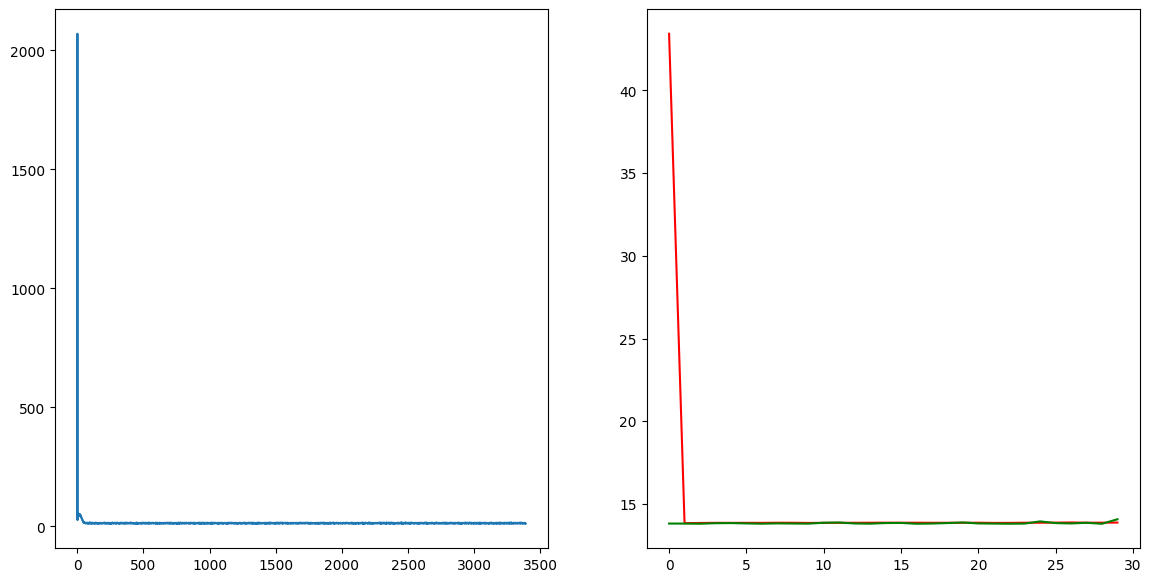

Current loss: 15.279434


In [176]:
net = make_net(net, optimizer, n_epoch, criterion, device)

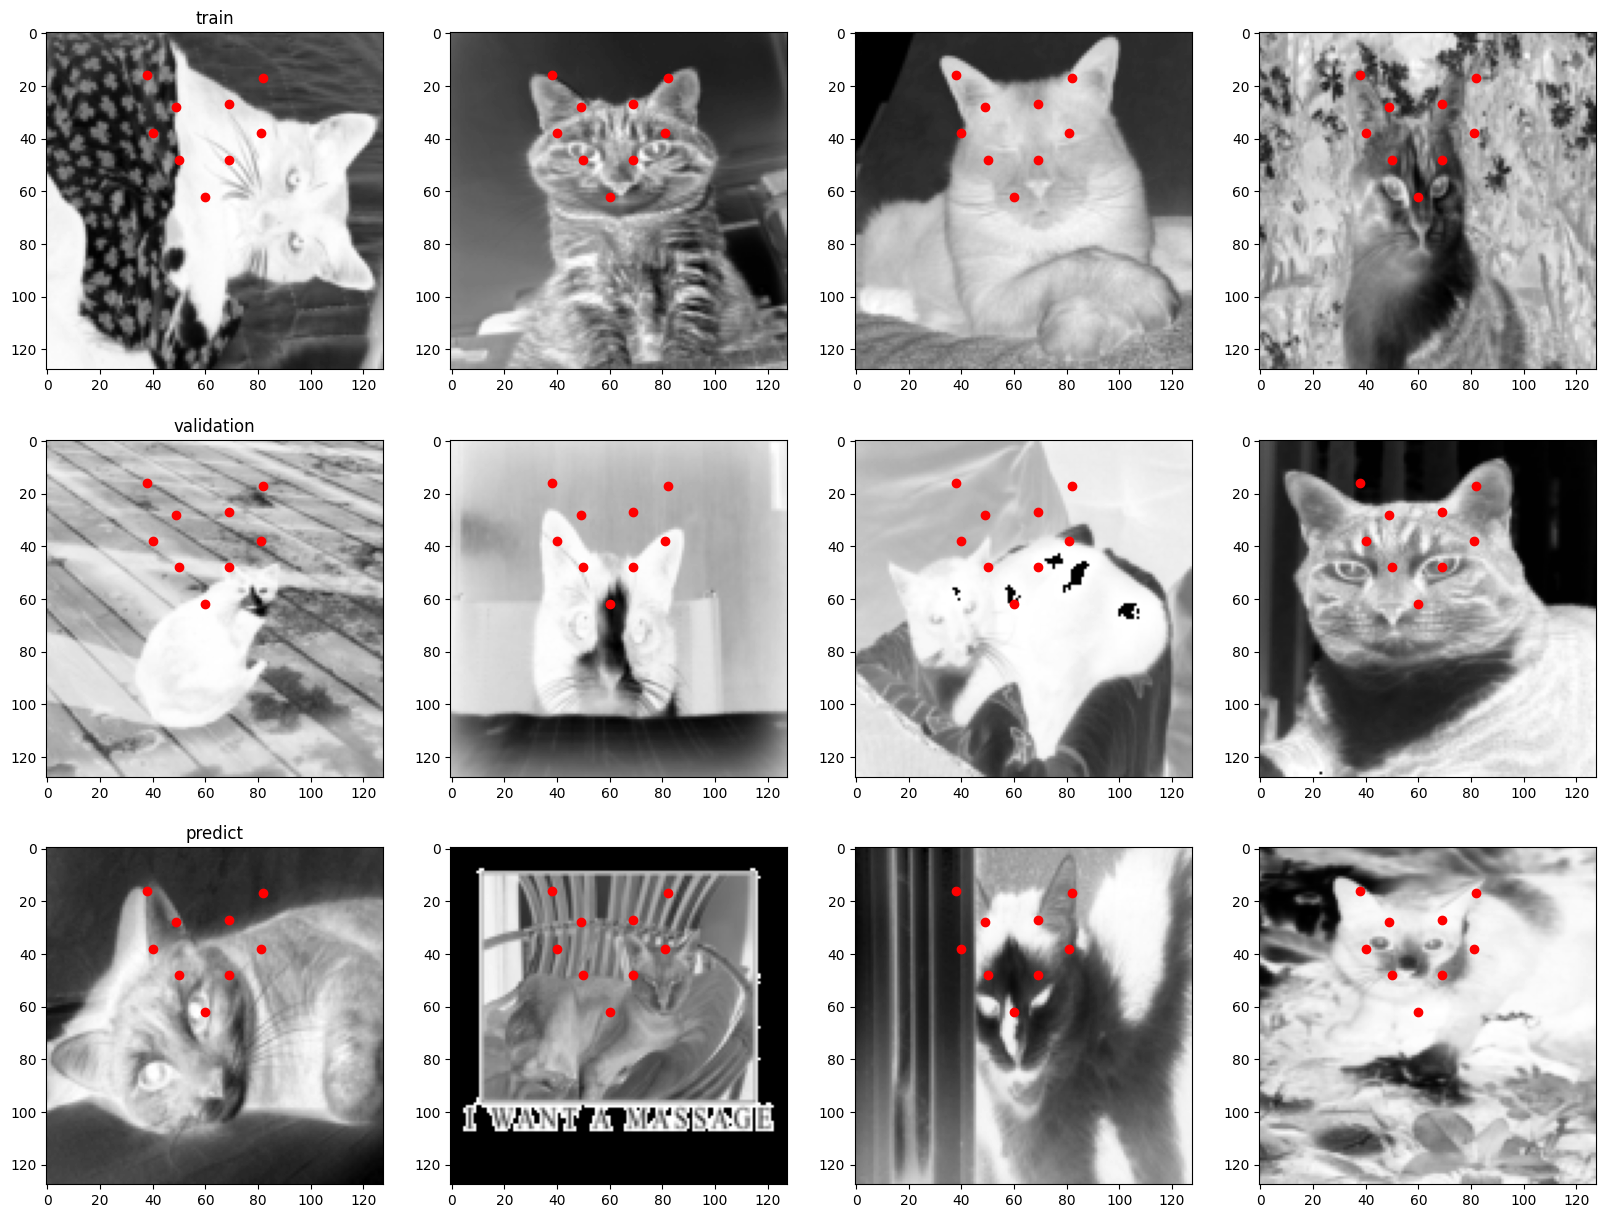

In [177]:
show_cats(net, test_dataloader, train_dataloader, val_dataloader) 

Как видно за 30 эпох эта сетка смогла:
Ничего. Выучила морду кота в общем.

Результат честно говоря очень такой себе. Ну и сеть тоже на многое не претендует.

#### Эксперимент 1.5

Тут не будет сетки, потому что я её потерял. Если первую сетку я даже не загружал на кегл, то вот эту я закинул. Получил 189, через день понял что забыл развернуть результаты к изначальынм размерам картинок, взял результаты, развернул, залил иииииииииии 51.

В этом кстати и кроется причина потери. Я подумал что если сеть сделанная на коленке выдает 51, то что на ней зацикливаться. И успешно начал её менять.
После чего не мог улучшить рещультат в течении ...

Фактически 14 сабмитов или 6 дней. Моделей конечно было больше, но я стабильно упирался примерно в 58-60 СМАЕ.

В какой-то момент я заметил, что мои сети не то чтобы учатся искать морду кота. Они выучивают общую форму морды, а потом бываются найти какое-то одно оптимальное положение для всей train выборки.

Посмотрев на формулу для СМАЕ я подумал, что можно посчитатть такую позицию ручками(а может и бейзлайн пройти, чем чёрт не шутит). 

Логика какова, наше СМАЕ это сумма модулей разности. Сумму модулей снизу можно оценить модулем суммы. Что я и сделал, и тогда получим для train датасета оценку каждого выхода сети вида x1 = summ(xi)/n. 
Только важная ремарочка, это ПОСЛЕ сжатия картинок, потом этот общий предикт надо разжать.

После я просто из интереса залил это в кегл и получил результат сравнимый с нейросетями.

Если интересно, то это result16. 

214.84375,157.08984375,281.25,157.08984375,248.046875,201.97265625,173.828125,130.16015625,164.0625,65.828125,214.84375,101.734375,281.25,101.734375,332.03125,65.828125,322.265625,131.65625,03fdf8df6de6684cc05c97114b68bf53.jpg


214.84375,153.80859375,281.25,153.80859375,248.046875,197.75390625,173.828125,127.44140625,164.0625,64.453125,214.84375,99.609375,281.25,99.609375,332.03125,64.453125,322.265625,128.90625,03ffe4d263e39734aa2ad49fdca2bf35.jpg

Вот например разные картинки, но предикт на первую координату совпадает с точностью до цифры. Это вот собственно потому что этот предикт и был один))). Опыт интересный но бейзлайн не пробило. Да и нейросетью это назвать тоже нельзя, так что если бы пробило я бы просто истерически посмеялся.

#### Эксперимент 2

Я не мог пробить бейзлайн 6 дней. Все модели которые я делал фактически делали одно и то же. Но я об этом уже писал. Вообще модели не сильно отличались от первой. Менялись количества слоев и размеры ядра и так далее. И вот так 6 дней непонимания. В какой-то момент я так отчаялся что пошёл и переписал считывание данных тк подумал что я их где-то ломаю по дороге. Ну не могут же все сети давать идентичный результат, правда ведь? Оказалось могут. если ставить learning rate = 0.1. 

Как сказал бы Шерлок Холмс "дело одной выукренной трубки". Как скажу я "Дело одной дырки в стене пробитой своей головой в попытках понять, что не так". 

In [189]:
net = nn.Sequential(
    nn.Conv2d(1, 16, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(64, 18, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(648, 128),
    nn.ReLU(),
    nn.Linear(128, 18)
)

In [191]:
n_epoch = 30
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.L1Loss()

In [192]:
device = 'cuda'
net.to(device)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Conv2d(64, 18, kernel_size=(3, 3), stride=(1, 1))
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=648, out_features=128, bias=True)
  (14): ReLU()
  (15): Linear(in_features=128, out_features=18, bias=True)
)

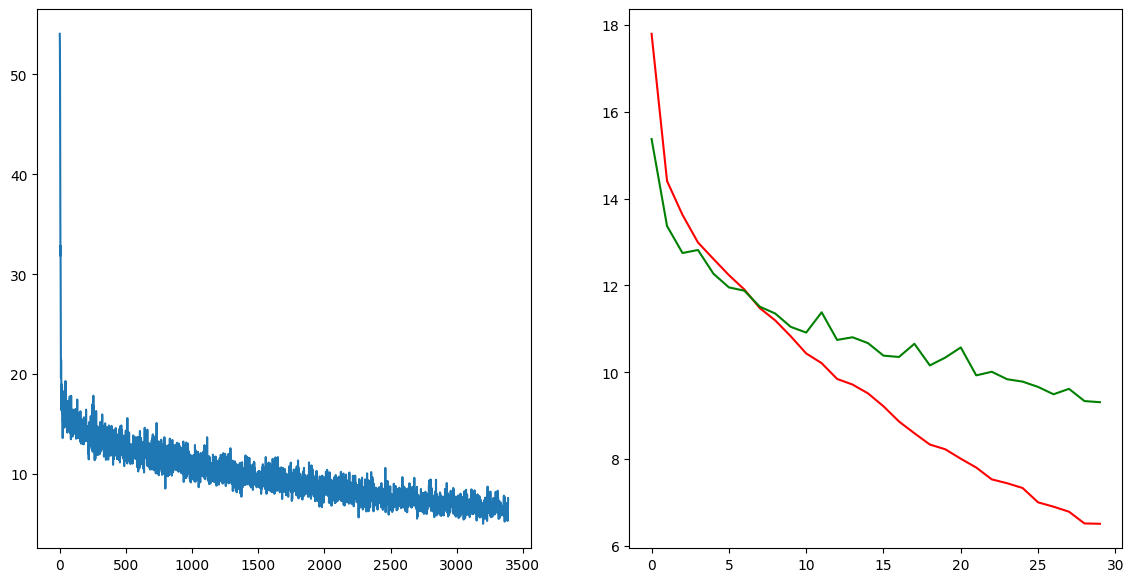

Current loss: 8.611588


In [193]:
net = make_net(net, optimizer, n_epoch, criterion, device)

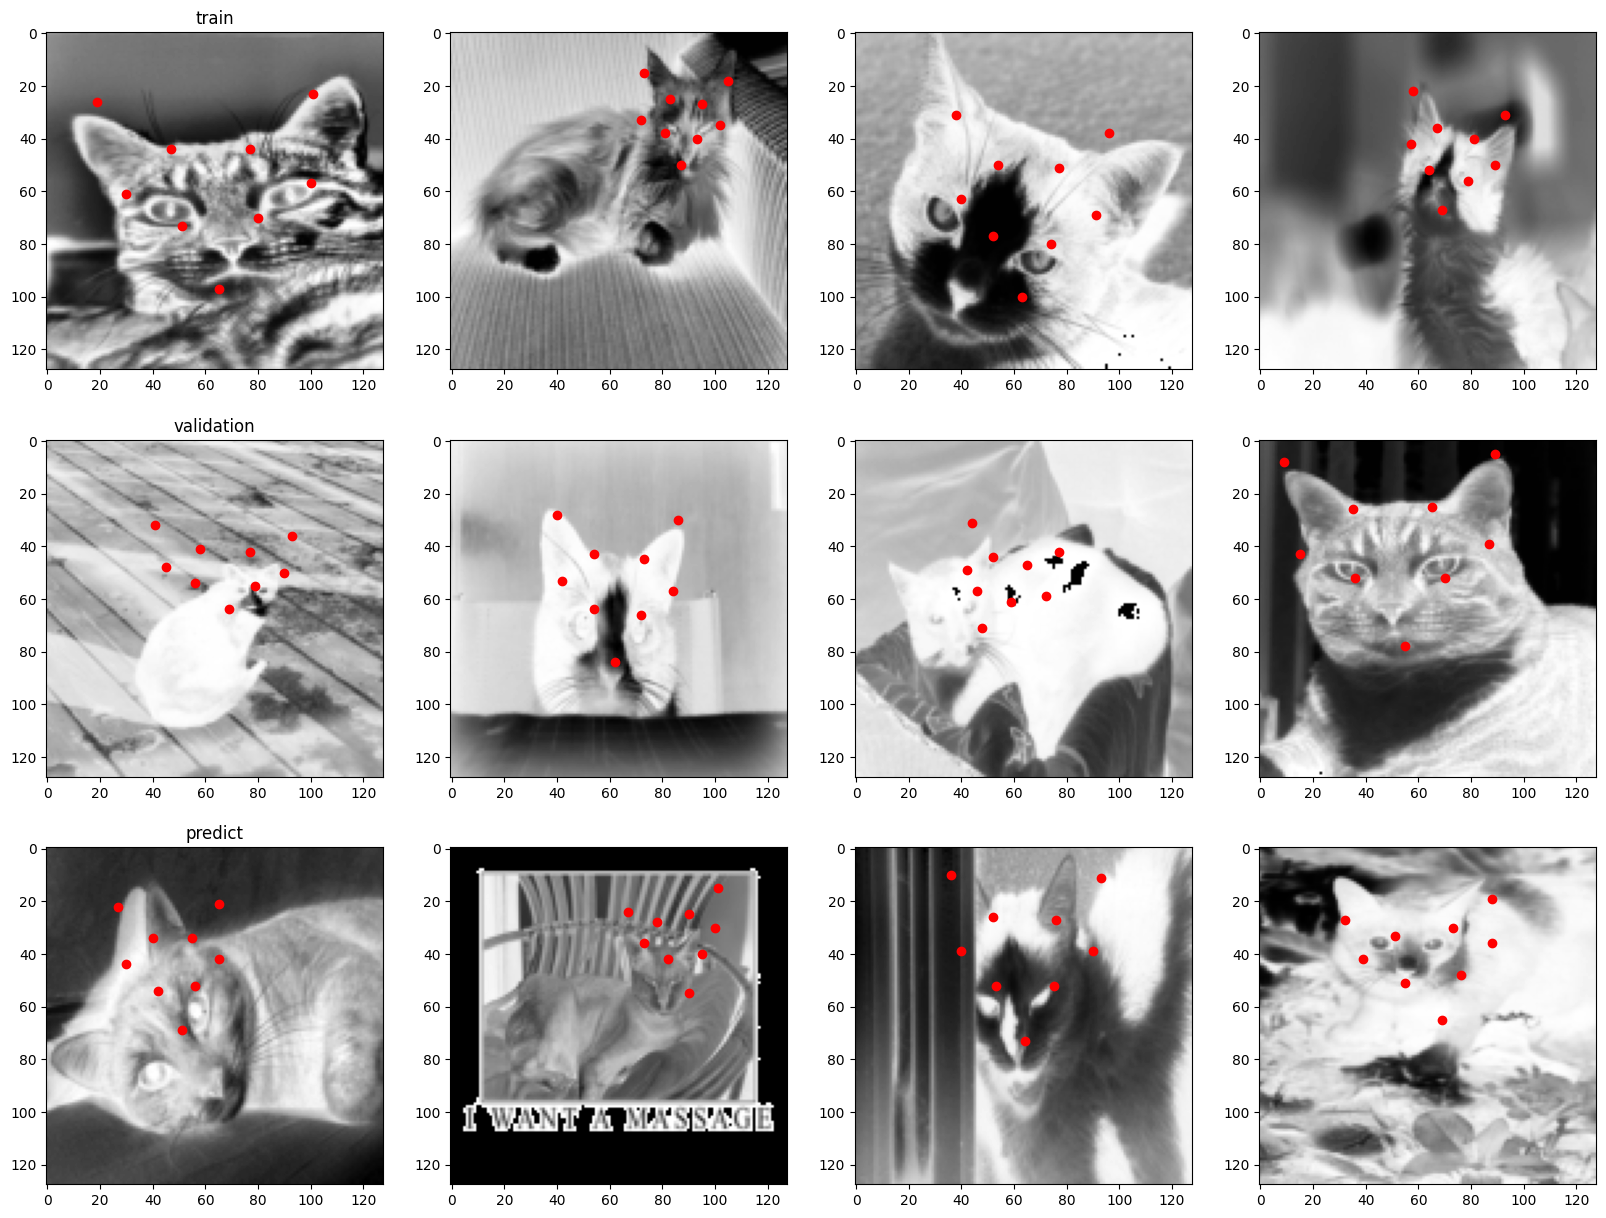

In [194]:
show_cats(net, test_dataloader, train_dataloader, val_dataloader)

Вот это уже по-моему должно блыо пробить бейзлайн(Честно я это не перепроверял). С натяжкой но тем не менее. Оно уже умеет чуть-чуть понимать где у кота морда и двигается примерно куда-то туда.

Тех котов что стоят анфас она даже неплохо определяетю

#### Эксперимент 3

Тут врать не буду, дальше я полез читать про неросети которые ищут какие-то ключевые точки на изображениях. Ну и про поиск точек лица тоже. Из них я вынес для себя пару вещей.

1) Макспулинг после каждой свертки не очень хорошо.
2) Batchnorm хорошо

Лично от себя поменял функцию активации в полносвязной части нейросети на сигмоиду.

Также поигрался с количеством эпох. Ниже будет видно будто мы эпохе на 15 выходим на плато. А вот оказывается что нетъ. Есть ещё куда расти.

In [14]:
net = nn.Sequential(
    nn.Conv2d(1, 16, 7, 2),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.Conv2d(16, 32, 5, 2),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, 5,2),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 64, 3),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128, 64, bias=True),
    nn.Sigmoid(),
    nn.Linear(64, 18, bias=True),
)

In [15]:
n_epoch = 60
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.L1Loss()

In [16]:
device = 'cuda'
net.to(device)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(7, 7), stride=(2, 2))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(32, 32, kernel_size=(5, 5), stride=(2, 2))
  (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU()
  (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (14): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (15): ReLU()
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Flatten(start_dim=

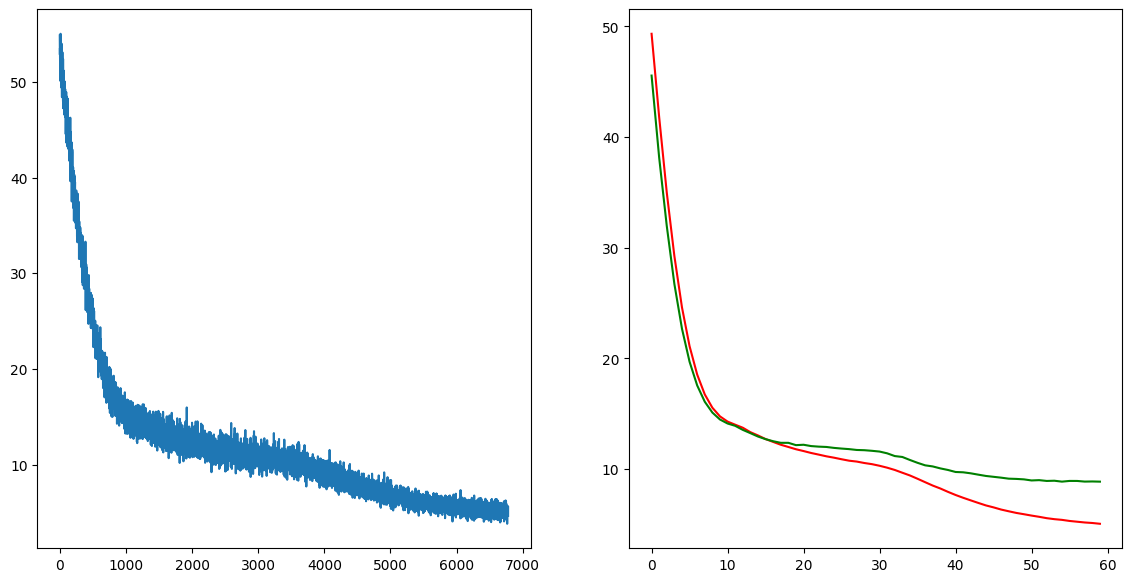

Current loss: 9.172282


In [217]:
net = make_net(net, optimizer, n_epoch, criterion, device)

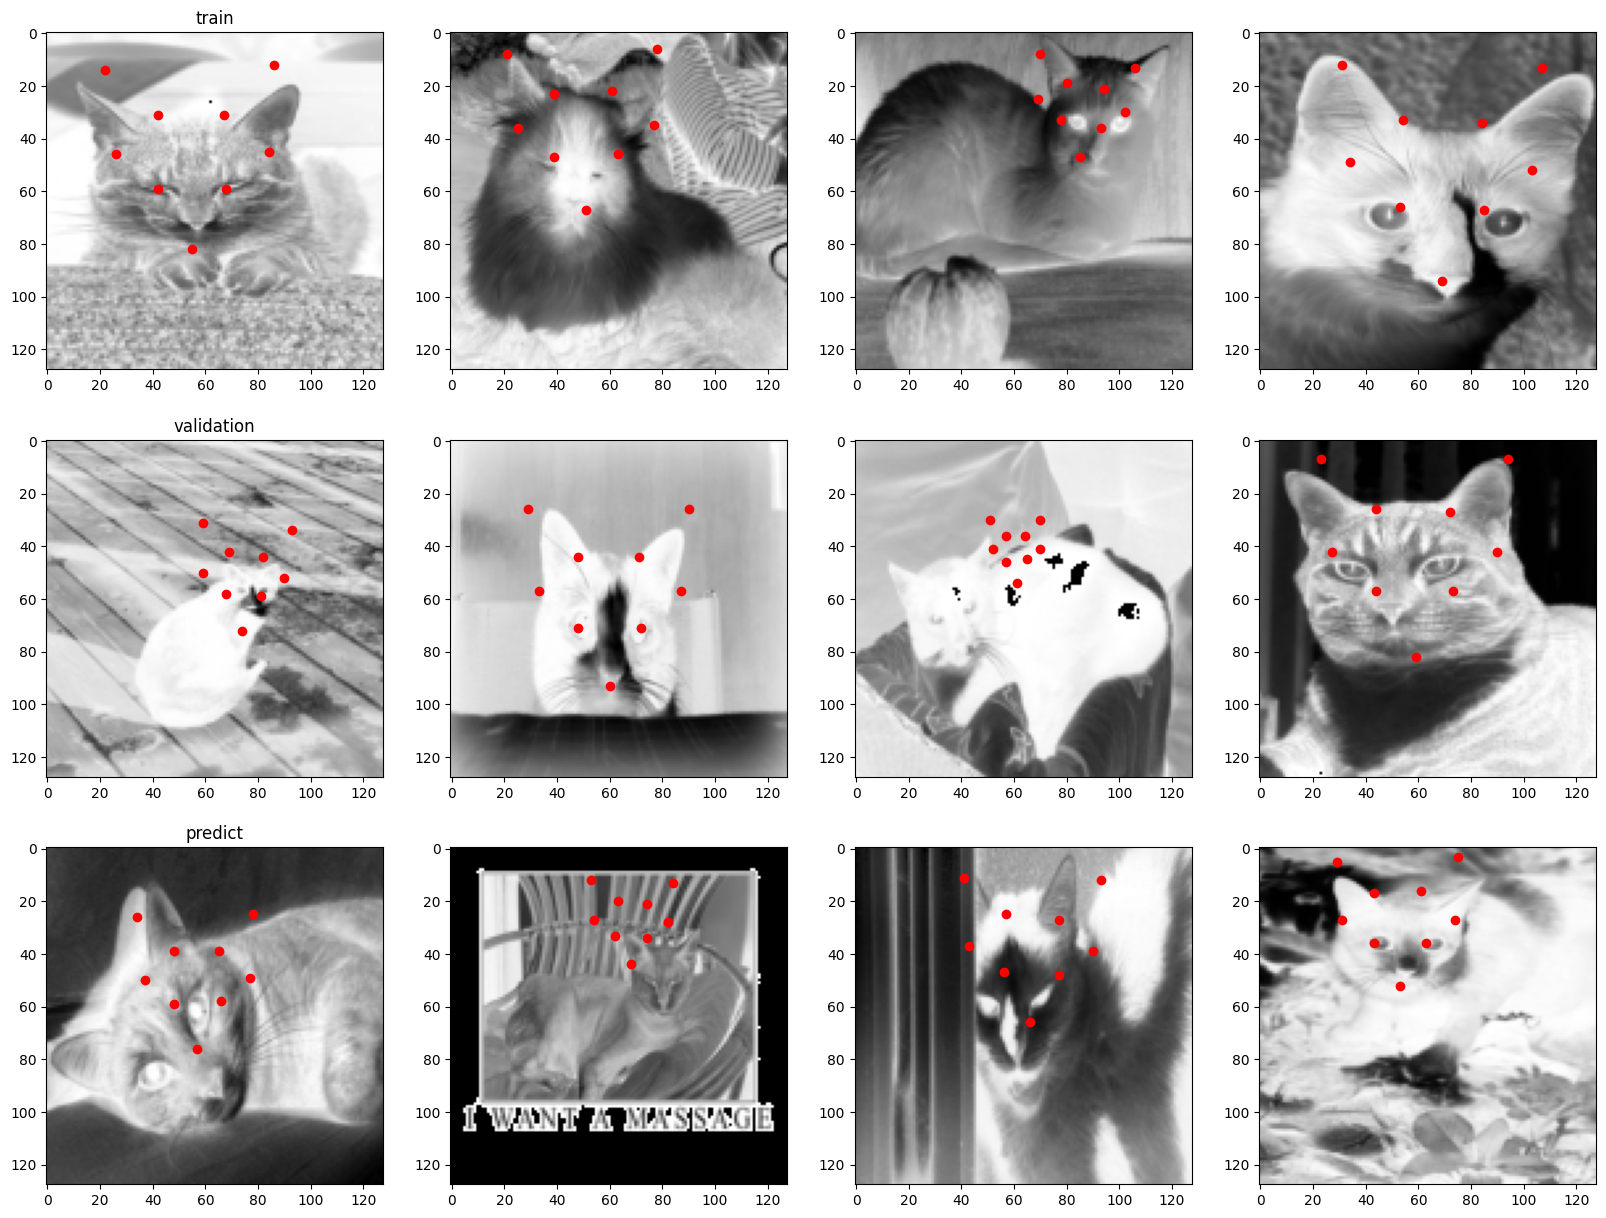

In [218]:
show_cats(net, test_dataloader, train_dataloader, val_dataloader)

Эта сеть в среднем более или менее неплохо попадает в рот и глаза, но вот с ушами есть трудности.

А ещё ОГРОООООООООООМНАЯ проблема всех моих сетей, которую я так и не решил это повороты головы.

Я вот как не бился, так ничего и не придумал.

#### Эксперимент 4

Вот тут я подумал что макспулинг это не единственный способ ... извлечения данных? Не уверен как это правильно назвать, ну в общем, макспулинг не единственный пулинг.

Эта мысль привела меня к чему-то вот такому

In [42]:
net = nn.Sequential(
nn.Conv2d(1, 16, 10, padding= 'same'),
nn.ReLU(),
nn.BatchNorm2d(16),
nn.Conv2d(16, 32, 7, padding= 'same'),
nn.ReLU(),
nn.BatchNorm2d(32),
nn.MaxPool2d(2),
nn.Conv2d(32, 64, 5, padding= 'same'),
nn.ReLU(),
nn.BatchNorm2d(64),
nn.AvgPool2d(3),
nn.Conv2d(64, 128, 3, padding= 'same'),
nn.ReLU(),
nn.BatchNorm2d(128),
nn.MaxPool2d(2),
nn.Flatten(),
nn.Linear(12800, 2048),
nn.Sigmoid(),
nn.Linear(2048, 18),
)

In [43]:
n_epoch = 30
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.L1Loss()

In [48]:
device = 'cuda'
net.to(device)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(10, 10), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Conv2d(16, 32, kernel_size=(7, 7), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (8): ReLU()
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): AvgPool2d(kernel_size=3, stride=3, padding=0)
  (11): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (12): ReLU()
  (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (15): Flatten(start_dim=1, end_dim=-1)
  (16): Linear(in_features=12800, 

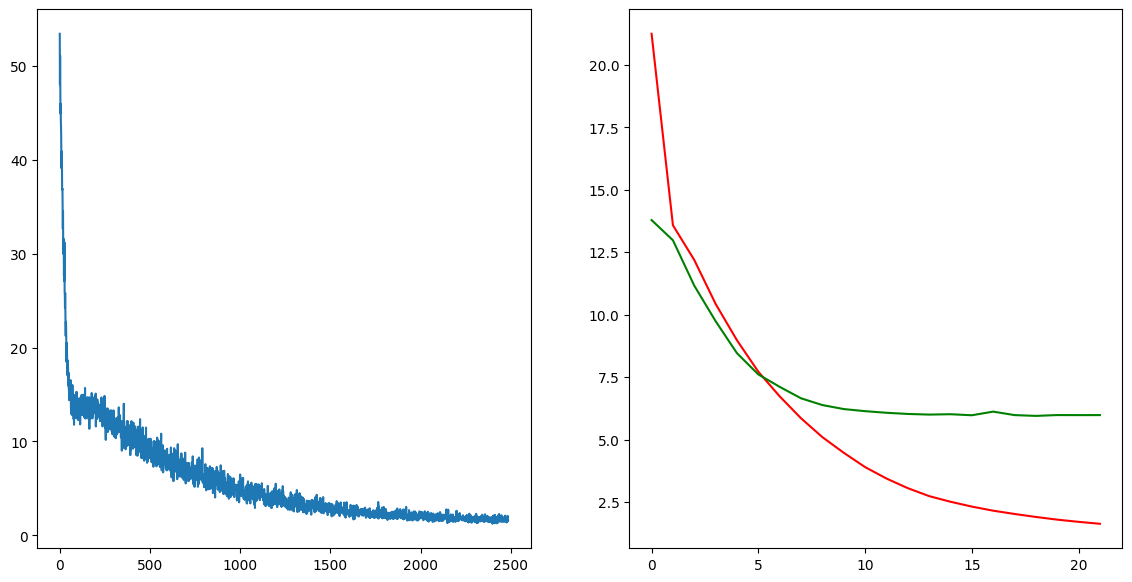

Current loss: 8.237848


KeyboardInterrupt: 

In [45]:
net = make_net(net, optimizer, n_epoch, criterion, device)

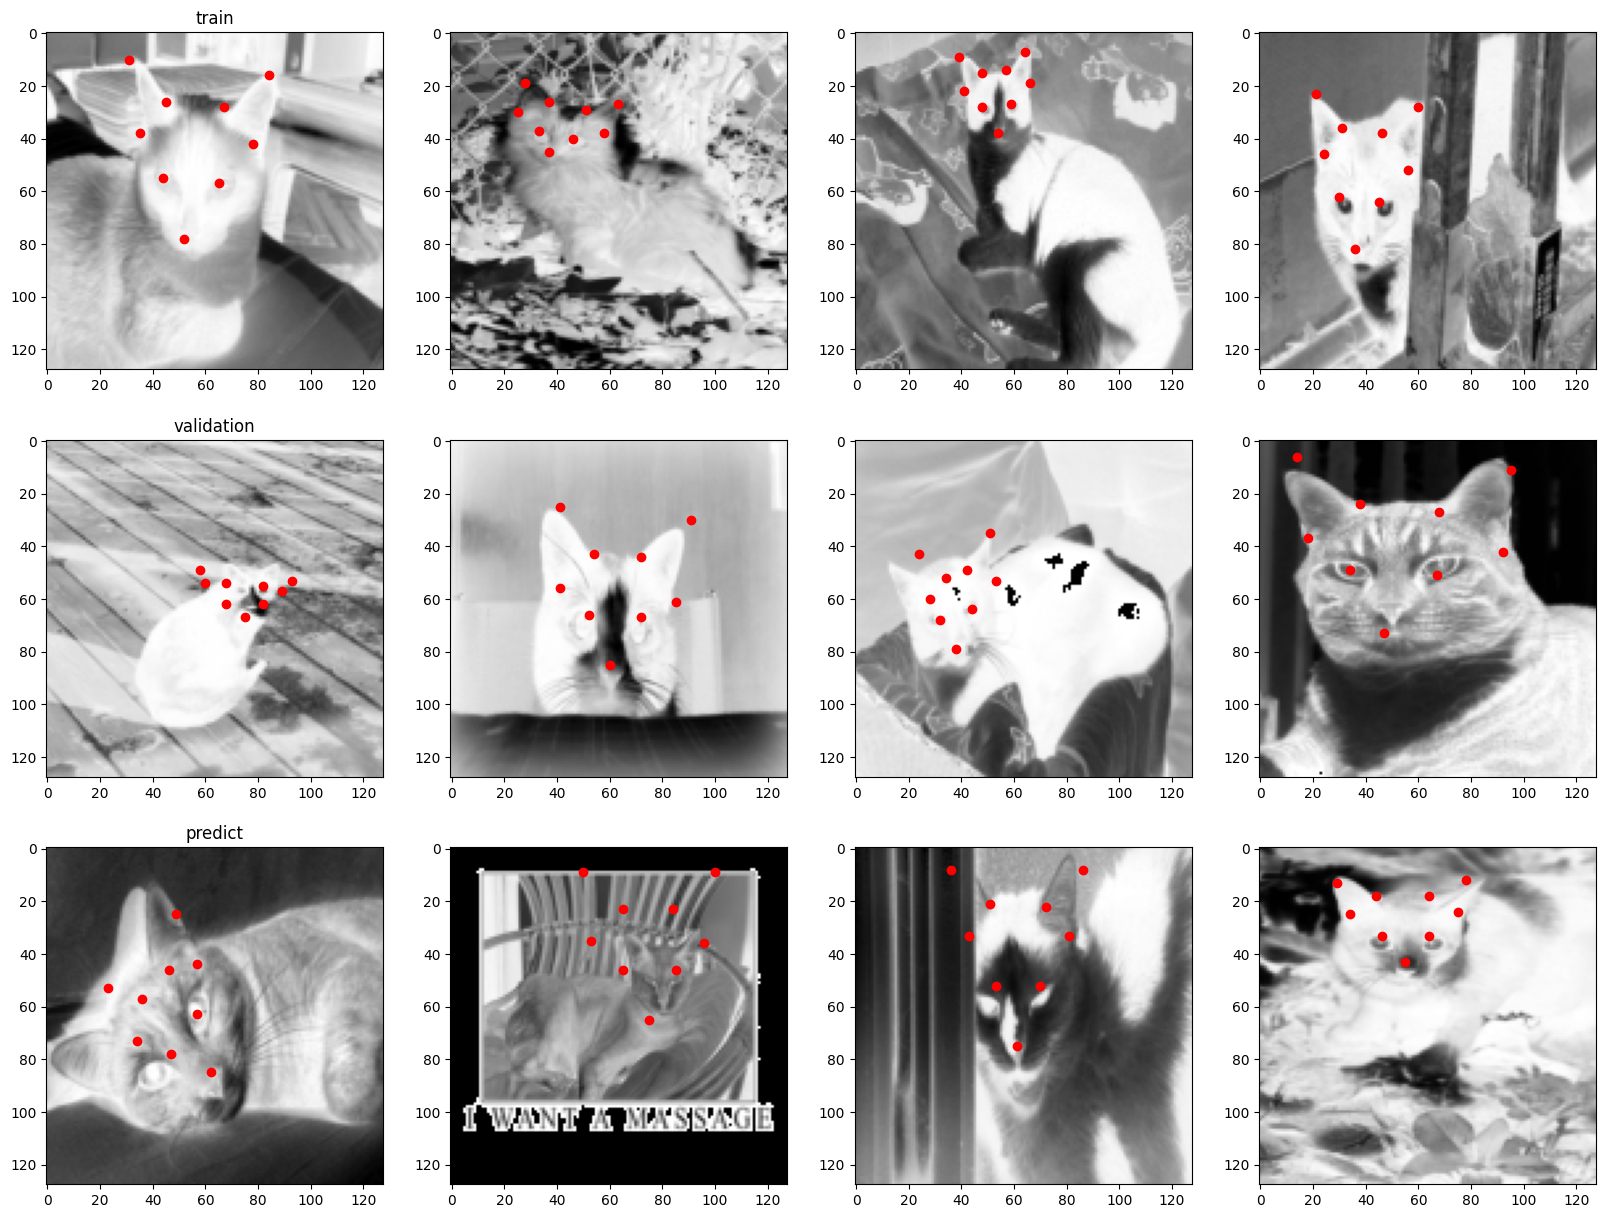

In [49]:
show_cats(net, test_dataloader, train_dataloader, val_dataloader)

Мне честно говоря тут даже сказать нечего, я подумал что можно добавить avg пулинг и добавил.

В целом можно видеть что модель справляется очень даже неплохо. Хотя 30 эпох для неё многовато. 13-15 в самый раз. Но крутить морду она так и не научилась.

Пытается но всё как-то нетъ.

#### Эксперимент 5

Глобально это не то чтобы что-то новое, скорее я поигрался с предыдущей моделью и это выдало мне лучший score. 

Из изменений:

1) Теперь не все свертки сохраняют размер
2) Увеличено число каналов

In [96]:
net = nn.Sequential(
nn.Conv2d(1, 32, 10, padding= 'same'),
nn.ReLU(),
nn.BatchNorm2d(32),
nn.Conv2d(32, 64, 5),
nn.ReLU(),
nn.BatchNorm2d(64),
nn.MaxPool2d(2),
nn.Conv2d(64, 128, 5),
nn.ReLU(),
nn.BatchNorm2d(128),
nn.AvgPool2d(3),
nn.Conv2d(128, 256, 3, padding= 'same'),
nn.ReLU(),
nn.BatchNorm2d(256),
nn.MaxPool2d(2),
nn.Flatten(),
nn.Linear(20736, 2048),
nn.Sigmoid(),
nn.Linear(2048, 18),
)

In [97]:
n_epoch = 15
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.L1Loss()

In [98]:
device = 'cuda'
net.to(device)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(10, 10), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1))
  (8): ReLU()
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): AvgPool2d(kernel_size=3, stride=3, padding=0)
  (11): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (12): ReLU()
  (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (15): Flatten(start_dim=1, end_dim=-1)
  (16): Linear(in_features=20736, out_features=2048, bias=T

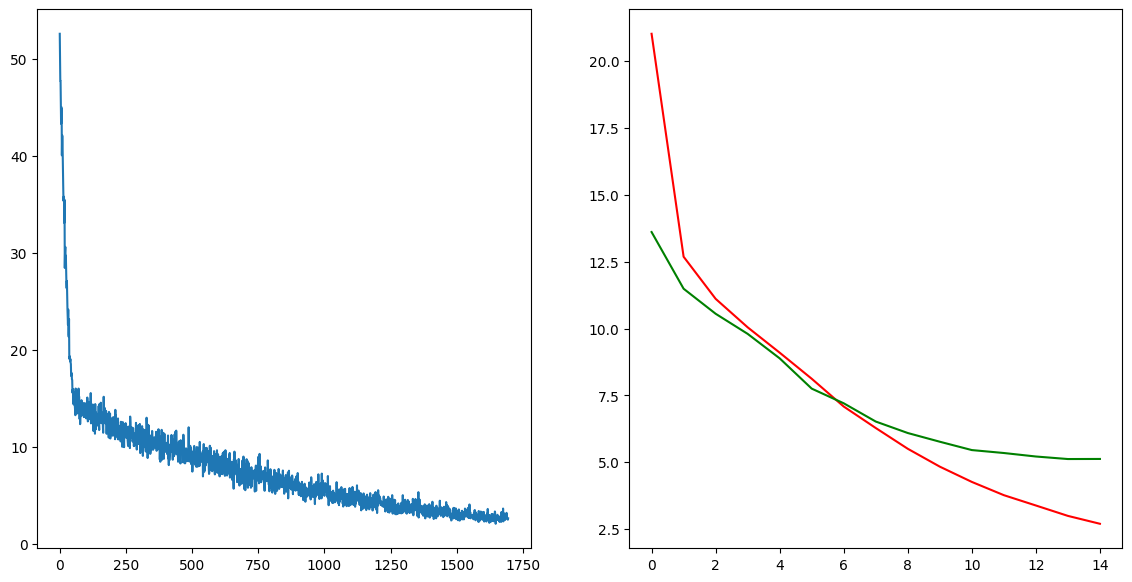

Current loss: 6.701971


In [99]:
net = make_net(net, optimizer, n_epoch, criterion, device)

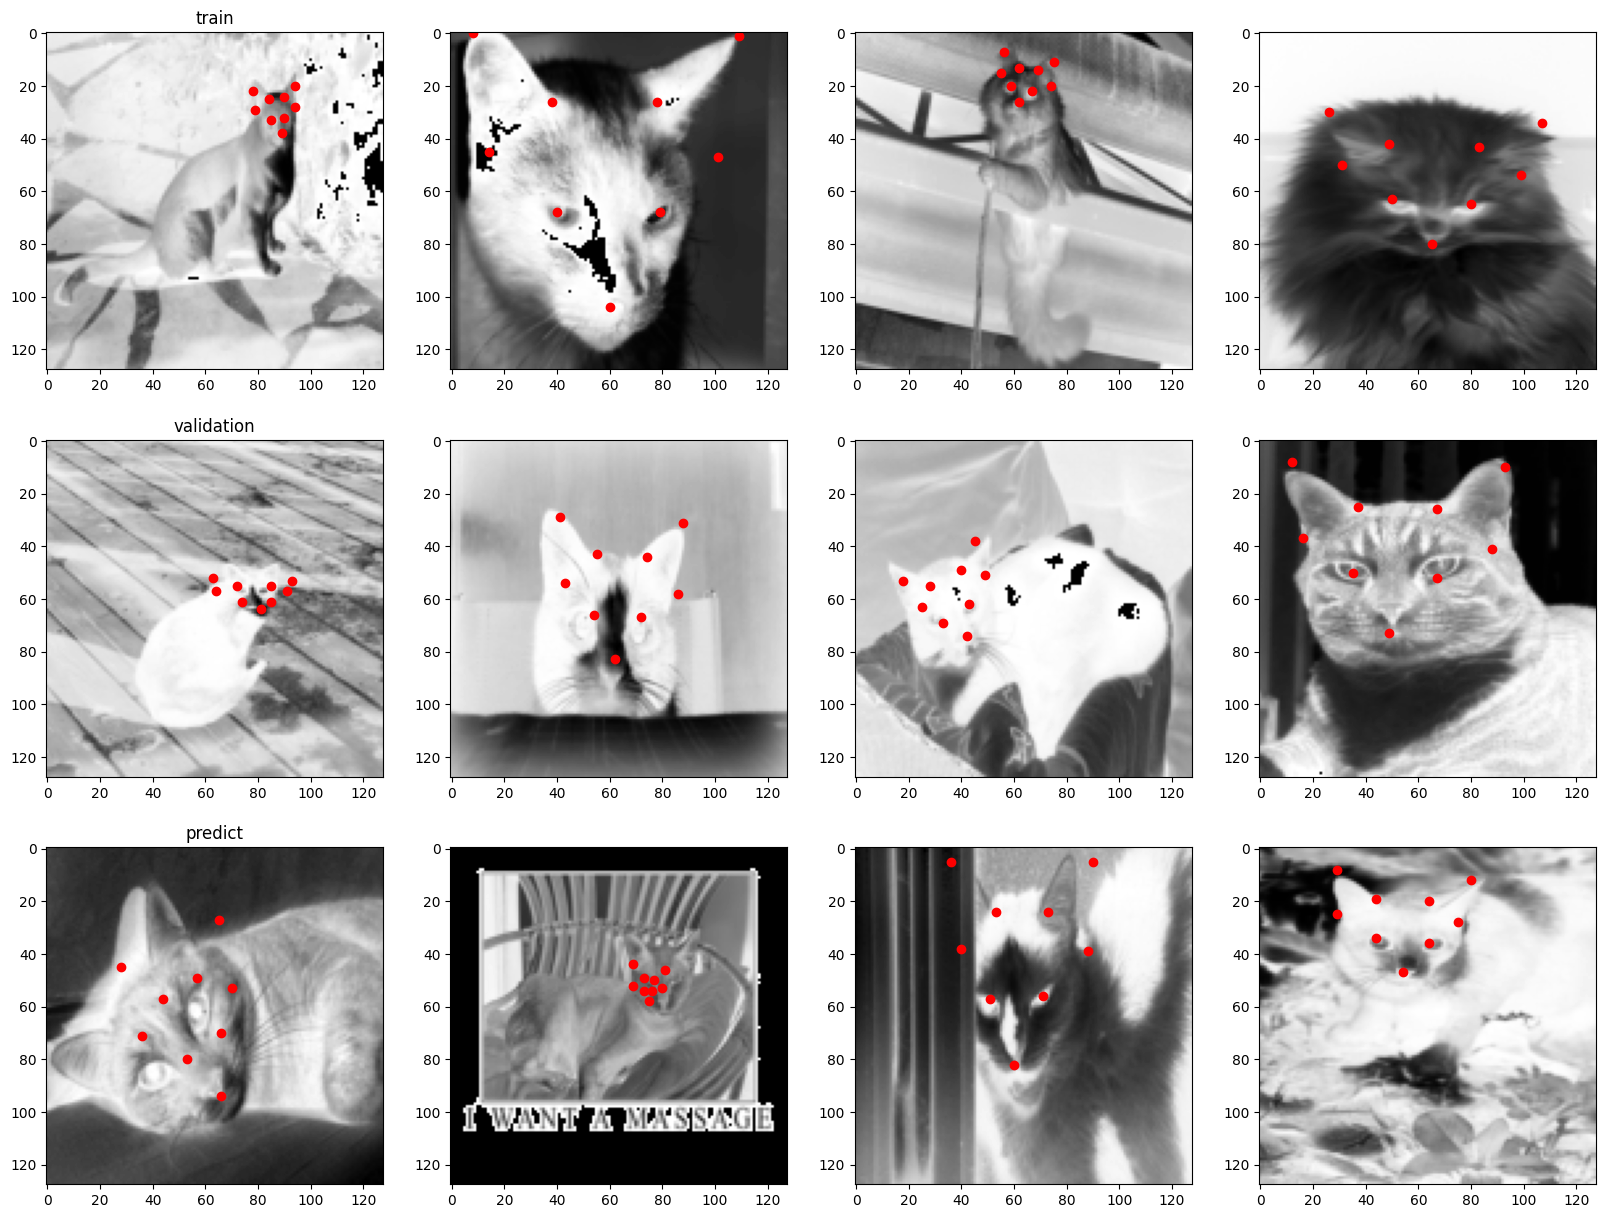

In [100]:
show_cats(net, test_dataloader, train_dataloader, val_dataloader)

Глобально внешне ничего не поменялось но скор маленько упал))

### Немного о том что ещё было

По поводу вращения картинок. Я очень надеялся, что смогу улучшить результат и научить сеть видеть повороты искуственно увеличив датасет добавив повернутые картинки. Но это вообще не помогло.

Какой-то новой архитектуры для этого я не придумывал, и брал те что уже сделал. И глобально я получал три результата:

1) Сеть поняла в какую сторону повернут кот, но определить его морду это было уже выше сил сети. Такое правда происходило в основном когда я добавлял много рандомных поворотов. Мой личный рекорд увеличить датасет в 8 раз.
2) Сеть неплохо понимает морду, но крутить её не может.
3) Сеть ничего она не поняла.

Может быть тема с поворотами хорошо отработала бы на более сложной сети, или с изображением 256х256.

Была модель где я чередовал maxpooling и avgpooling несколько раз. Она долго училась. И выучила ту самую морду кота на 58 мае.

Была модель такая же как лучшая но вместо maxpooling был avgpooling и наоборот. Научилась примерно тому же самому.

Ну и огроооооооооомная куча разных моделей с минимальными изменениями. 

Больше ничего сверх интересного.

### Evaluation  (оценка качества модели)

In [101]:
res, test_preds = make_preds(net, data.columns, test_dataloader)

In [102]:
res

,left_eye_x,left_eye_y,right_eye_x,right_eye_y,mouth_x,mouth_y,left_ear_1_x,left_ear_1_y,left_ear_2_x,left_ear_2_y,left_ear_3_x,left_ear_3_y,right_ear_1_x,right_ear_1_y,right_ear_2_x,right_ear_2_y,right_ear_3_x,right_ear_3_y,file_name
0,429.526550,483.089996,533.471802,422.386597,535.670349,564.374542,295.093353,431.182159,229.504349,275.756790,354.571991,345.068253,460.808411,294.079582,524.231262,166.984795,561.702271,323.622414,00271b0b4a63cd445eb573b955c13436.jpg
1,287.098467,171.573555,299.939066,171.656108,293.586522,182.600594,271.497399,162.552309,271.562904,139.605498,285.842359,155.583727,304.608285,157.417631,316.789448,144.661331,313.584864,168.553770,0122897dbb3886ced713c9e1834e299d.jpg
2,408.742188,301.730994,573.748657,295.527395,481.332825,435.955820,322.700836,202.328485,290.159302,30.580227,427.038025,130.308845,588.019958,127.174022,725.115112,29.361972,704.123779,208.370204,015e123029f3d243c4d96de7e47dc0b9.jpg
3,113.181700,134.604290,164.018006,140.721291,139.213093,185.033128,76.015822,98.188519,74.546366,34.517884,113.440635,75.708233,165.547467,80.676332,206.091455,49.101263,194.446950,111.566633,0176c49df9745e5f2b1bfa5bec219739.jpg
4,239.843726,152.806766,293.234020,157.563753,271.463990,178.922072,191.580474,139.625005,191.265911,103.237141,233.883932,125.950713,289.692849,128.794089,334.222972,109.991703,314.994156,147.123322,018241810afc650fdb27922b96d5b3c1.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,271.795164,326.887421,428.997414,326.350189,332.746297,433.195618,199.499179,280.451691,170.566357,121.388245,290.326873,211.904861,449.299233,209.356964,573.319477,131.071793,551.265623,297.539337,ff74338d2fd502a16d3fc02aa4f95e35.jpg
996,384.464859,255.744583,469.346832,255.416626,425.139221,341.728088,329.343658,204.124222,326.547249,66.308220,391.815903,155.758362,471.841095,157.852539,535.288696,88.095627,526.662689,218.385818,ff84973cca2b3a9a039e0c26e1d71060.jpg
997,200.521834,146.512672,247.629404,156.741142,220.614888,189.091429,166.224092,112.777442,170.260537,55.993211,202.841453,95.111817,255.418807,105.853818,295.851432,87.687537,279.004209,140.798882,ff8d452e68b2e44d8278c700e9601afe.jpg
998,128.223419,172.009662,191.269875,170.758523,156.878978,235.036075,93.854062,131.187737,81.290960,47.148529,136.655390,98.144777,193.787605,99.304307,244.950220,48.590066,239.534393,133.648697,ff91f36ac0a302504645719511bc312c.jpg


In [103]:
res.to_csv('result_final.csv', index=False)

Ну метрику можно примерно оценить по графику ~6. А в кегле ~20.5+-1

### Conclusion (Выводы)

Ну вроде модель получилась достаточно неплохая. В этот раз даже catboost не сделал всё за меня, потому что в этот раз за меня всё сделал Torch. 

В целом я доволен тем что получилось. А чем я недоволен так это тем, что я много дней не мог сдвинуться с мёртвой точки.

По итогу времени на эксперименты уже не так и много осталось. Ну бейзлайн пробил с хорошим отрывом так что ладно.